# Chapter 98 — Intersections

> **Prerequisites:** ch097 (Line Equations)
>
> **Outcomes:** Find line-line, line-circle, and circle-circle intersections; Solve 2×2 linear systems geometrically; Handle parallel/coincident lines


## Line-Line Intersection

Two lines a₁x+b₁y+c₁=0 and a₂x+b₂y+c₂=0 intersect where both equations hold simultaneously.

In matrix form: [a₁ b₁; a₂ b₂] [x; y] = [-c₁; -c₂]

Solution: [x; y] = A⁻¹ (-c)   provided det(A) ≠ 0.

Cases:
- det(A) ≠ 0: unique intersection
- det(A) = 0 and consistent: coincident lines (same line)
- det(A) = 0 and inconsistent: parallel lines (no intersection)

*(This is a 2×2 linear system — introduced in ch160 and solved by Gaussian elimination in ch161.)*

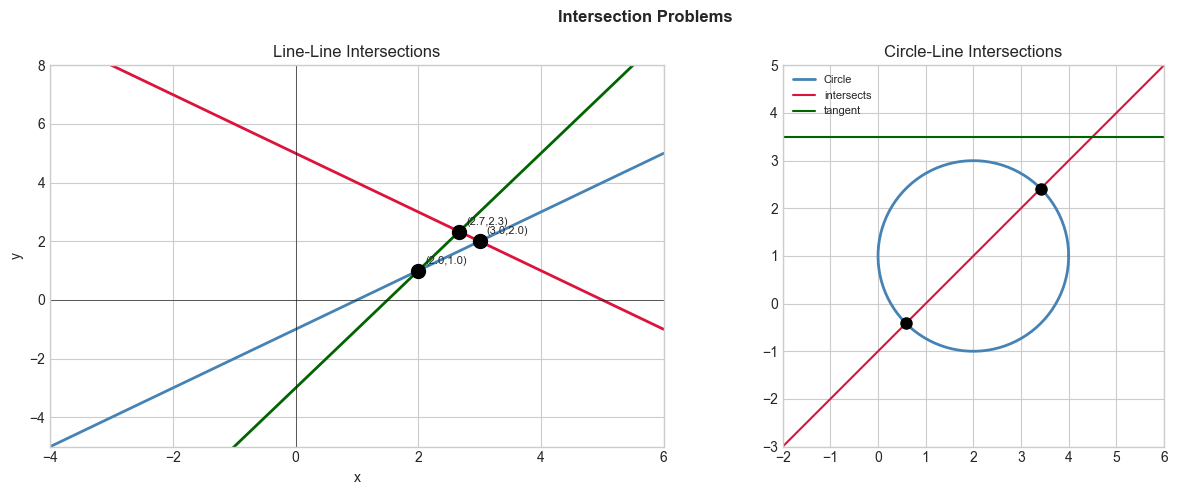

In [4]:
# --- Intersection solver ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def line_intersect(a1,b1,c1, a2,b2,c2):
    """Solve a1x+b1y+c1=0, a2x+b2y+c2=0. Returns (x,y) or None."""
    A = np.array([[a1,b1],[a2,b2]], dtype=float)
    rhs = np.array([-c1,-c2], dtype=float)
    det = np.linalg.det(A)
    if abs(det) < 1e-12: return None
    return np.linalg.solve(A, rhs)

def circle_line_intersect(cx,cy,r, a,b,c):
    """Circle center (cx,cy) radius r; line ax+by+c=0. Returns points list."""
    dist = abs(a*cx + b*cy + c) / np.sqrt(a**2+b**2)
    if dist > r + 1e-10: return []
    # Project center onto line, find tangent points
    foot_x = cx - a*(a*cx+b*cy+c)/(a**2+b**2)
    foot_y = cy - b*(a*cx+b*cy+c)/(a**2+b**2)
    if abs(r**2 - dist**2) < 1e-10:
        return [(foot_x, foot_y)]
    half = np.sqrt(max(0, r**2 - dist**2))
    t = half / np.sqrt(a**2+b**2)
    return [(foot_x + b*t, foot_y - a*t), (foot_x - b*t, foot_y + a*t)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.linspace(-4, 6, 300)

# Line-line intersections
lines = [(-1,1,1), (1,1,-5), (-2,1,3)]  # ax+by+c=0
colors = ['steelblue','crimson','darkgreen']
for (a,b,c),col in zip(lines,colors):
    if abs(b) > 1e-10:
        axes[0].plot(x, (-a*x-c)/b, color=col, linewidth=2)
for i in range(len(lines)):
    for j in range(i+1,len(lines)):
        pt = line_intersect(*lines[i], *lines[j])
        if pt is not None:
            axes[0].plot(*pt,'ko',markersize=10,zorder=5)
            axes[0].annotate(f'({pt[0]:.1f},{pt[1]:.1f})',pt,xytext=(5,5),textcoords='offset points',fontsize=8)
axes[0].set_xlim(-4,6); axes[0].set_ylim(-5,8); axes[0].set_title('Line-Line Intersections')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].axhline(0, color='k', linewidth=0.4); axes[0].axvline(0, color='k', linewidth=0.4)

# Circle-line intersections
theta = np.linspace(0,2*np.pi,200)
cx,cy,r = 2,1,2
axes[1].plot(cx+r*np.cos(theta),cy+r*np.sin(theta),'steelblue',lw=2,label='Circle')
for a,b,c,col,lbl in [(-1,1,1,'crimson','intersects'),(0,1,-3.5,'darkgreen','tangent'),(1,0,-5,'orange','miss')]:
    if abs(b)>1e-10:
        axes[1].plot(x,(-a*x-c)/b,color=col,lw=1.5,label=lbl)
    pts = circle_line_intersect(cx,cy,r, a,b,c)
    for p in pts:
        axes[1].plot(*p,'ko',markersize=8,zorder=5)
axes[1].set_xlim(-2,6); axes[1].set_ylim(-3,5); axes[1].set_aspect('equal')
axes[1].set_title('Circle-Line Intersections'); axes[1].legend(fontsize=8)

plt.suptitle('Intersection Problems', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Line-line: solve 2×2 linear system; det=0 → parallel or coincident
- Line-circle: distance from center to line vs radius determines 0, 1, or 2 intersections
- These are the building blocks of 2D collision detection

**Forward:** ch160 (Systems of Linear Equations) formalizes this for N lines in N dimensions.